<a href="https://colab.research.google.com/github/lakshyasahu111/Handwritten-Number-Recognition-using-Pytorch/blob/main/Handwitten_Number_Recognition_Using_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from torchvision import datasets
from torchvision.transforms import ToTensor
import warnings
import numpy as np
warnings.filterwarnings("ignore", category=UserWarning)



In [3]:
train_data = datasets.MNIST(
    root='data',
    train=True,
    transform=ToTensor(),
    download=True
)

test_data = datasets.MNIST(
    root='data',
    train=False,
    transform=ToTensor(),
    download=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.9MB/s]


In [4]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [5]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [6]:
train_data.data.shape


torch.Size([60000, 28, 28])

In [7]:
test_data.data.shape

torch.Size([10000, 28, 28])

In [8]:
from torch.utils.data import DataLoader

loaders = {
    'train': DataLoader(train_data, batch_size=100, shuffle=True, num_workers=1),
    'test': DataLoader(test_data, batch_size=100, shuffle=True, num_workers=1)
}

In [9]:
loaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x7d6012473a10>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x7d60124795b0>}

In [10]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()

        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):

        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))

        x = x.view(-1, 320)

        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)

        x = self.fc2(x)

        return F.log_softmax(x, dim=1)

In [11]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [12]:
def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 20 == 0:
            print(f"Train Epoch: {epoch} [{batch_idx * len(data)} / {len(loaders['train'].dataset)} ({100 * batch_idx / len(loaders['train']):0f}%)]\t{loss.item():.6f}")

In [13]:
def test():
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_fn(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(loaders['test'].dataset)
    print(f"\nTest set: Average loss: {test_loss: 0.4f}, Accuracy {correct}/{len(loaders['test'].dataset)}  ({100 * correct / len(loaders['test'].dataset):.0f}%\n")

In [14]:
for epoch in range(1, 11):
    train(epoch)
    test()

Train Epoch: 1 [0 / 60000 (0.000000%)]	2.318072
Train Epoch: 1 [2000 / 60000 (3.333333%)]	2.120337
Train Epoch: 1 [4000 / 60000 (6.666667%)]	1.652900
Train Epoch: 1 [6000 / 60000 (10.000000%)]	1.122393
Train Epoch: 1 [8000 / 60000 (13.333333%)]	1.115616
Train Epoch: 1 [10000 / 60000 (16.666667%)]	0.725796
Train Epoch: 1 [12000 / 60000 (20.000000%)]	0.517288
Train Epoch: 1 [14000 / 60000 (23.333333%)]	0.546862
Train Epoch: 1 [16000 / 60000 (26.666667%)]	0.504922
Train Epoch: 1 [18000 / 60000 (30.000000%)]	0.517000
Train Epoch: 1 [20000 / 60000 (33.333333%)]	0.468575
Train Epoch: 1 [22000 / 60000 (36.666667%)]	0.588053
Train Epoch: 1 [24000 / 60000 (40.000000%)]	0.406301
Train Epoch: 1 [26000 / 60000 (43.333333%)]	0.370040
Train Epoch: 1 [28000 / 60000 (46.666667%)]	0.432470
Train Epoch: 1 [30000 / 60000 (50.000000%)]	0.514313
Train Epoch: 1 [32000 / 60000 (53.333333%)]	0.375011
Train Epoch: 1 [34000 / 60000 (56.666667%)]	0.519672
Train Epoch: 1 [36000 / 60000 (60.000000%)]	0.358446
Trai

In [15]:
device

device(type='cuda')

In [16]:
test_data.data.shape

torch.Size([10000, 28, 28])

In [17]:
test_data[0][1]

7

In [18]:


import matplotlib.pyplot as plt
def predict(idx):
    model.eval()
    # idx=np.random.randint(0, 10000)
    data,target=test_data[idx]
    data = data.unsqueeze(0).to(device)
    output = model(data)
    prediction = output.argmax(dim=1, keepdim=True).item()
    print(f"Prediction: {prediction}")
    image = data.squeeze(0).squeeze(0).cpu().numpy()
    if(prediction==target):
        print("Correct Prediction")
    else:
        print("Wrong Prediction")
    plt.imshow(image,cmap='gray');
    plt.show()



Prediction: 3
Correct Prediction


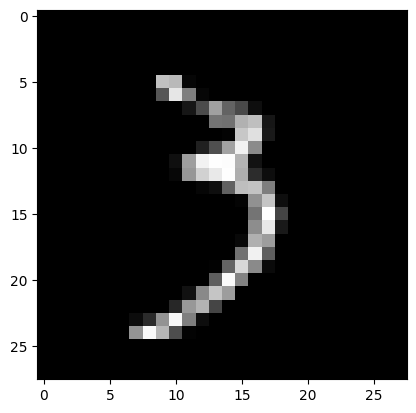

Prediction: 3
Correct Prediction


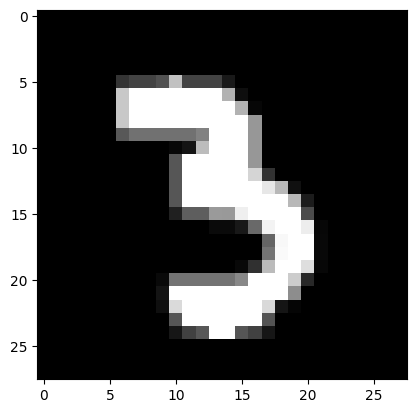

Prediction: 7
Correct Prediction


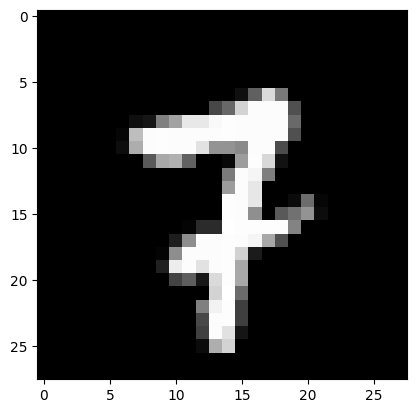

Prediction: 3
Correct Prediction


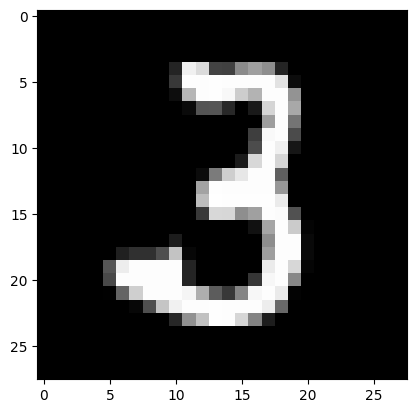

Prediction: 4
Correct Prediction


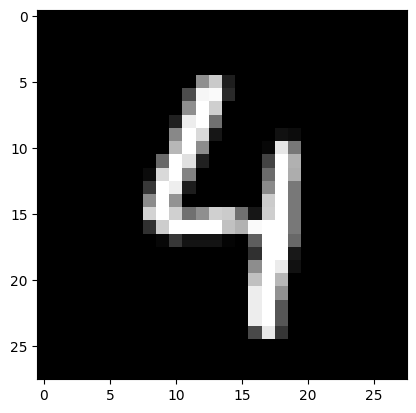

Prediction: 3
Correct Prediction


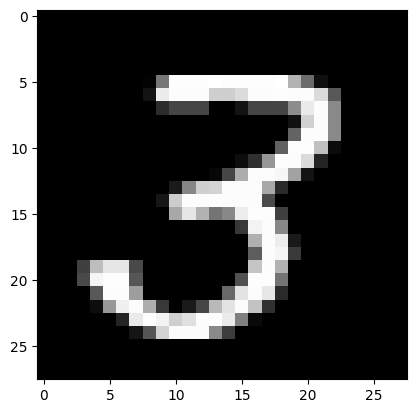

Prediction: 2
Correct Prediction


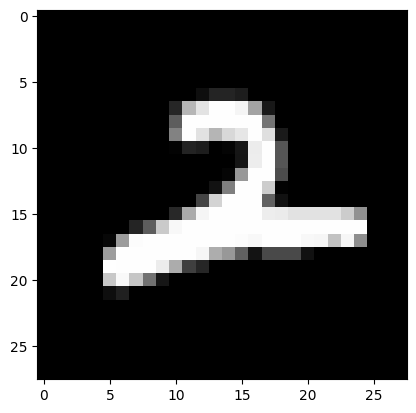

Prediction: 9
Correct Prediction


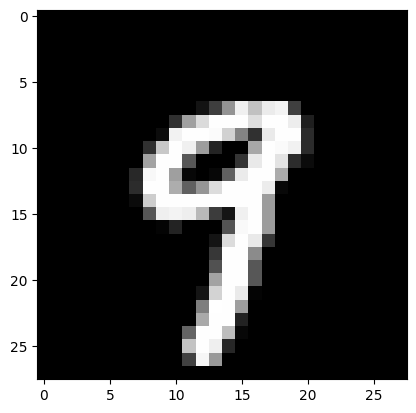

Prediction: 0
Correct Prediction


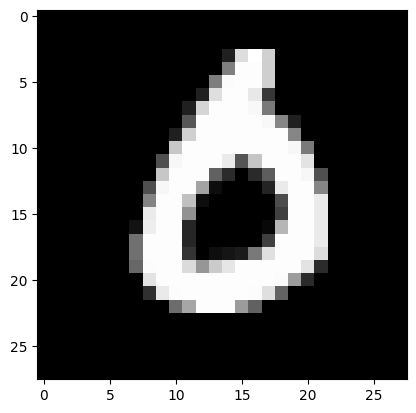

Prediction: 6
Correct Prediction


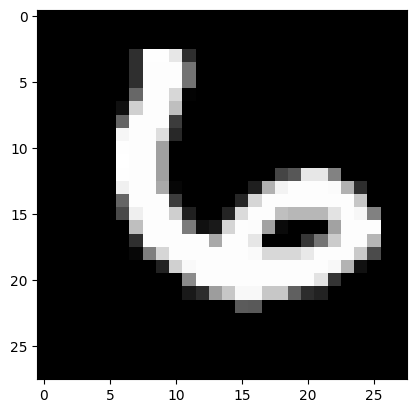

In [25]:
for i in range (1,11):
    idx=np.random.randint(1,10000)
    predict(idx)
